In [120]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from micom.workflows import load_results
from skbio.stats.composition import clr
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, cophenet
from matplotlib.lines import Line2D
from skbio.diversity import beta_diversity
from sklearn.preprocessing import StandardScaler

%matplotlib inline

### Preprocess the data by binarzing gene count matrix against presence/absence

In [140]:
gene_count = pd.read_csv('/Users/zetianzhang/UrtechoLab/human/processed/agora_metabolism/agora_metabolism-module_stepwise_completeness-MATRIX.txt', sep='\t')
taxonomy = pd.read_csv('/Users/zetianzhang/FMT/goll_et.al_2020_IBS_FMT/processed/reference_taxonomy.csv')
taxonomy['NCBI Taxonomy ID'] = taxonomy['NCBI Taxonomy ID'].astype('str').str.replace('.0', '', regex=False)
abundance = pd.read_csv('/Users/zetianzhang/FMT/goll_et.al_2020_IBS_FMT/processed/abundance_normalized_table.csv', index_col=0)
DonorRecipientMapping = pd.read_csv('/Users/zetianzhang/FMT/goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient'] = DonorRecipientMapping['recipient'].str.split('_').str[0]
donors = DonorRecipientMapping['donor'].unique().tolist()
recipients_t6 = DonorRecipientMapping['recipient'].str.replace('-0', '-6').tolist()
recipients_t0 = [recipient.replace('-6', '-0') for recipient in recipients_t6]
all_samples = set(donors+recipients_t0+recipients_t6)
growth_rates = load_results('/Users/zetianzhang/FMT/goll_et.al_2020_IBS_FMT/models/res_western.zip').growth_rates
exchanges = load_results('/Users/zetianzhang/FMT/goll_et.al_2020_IBS_FMT/models/res_western.zip').exchanges
model_samples = set(growth_rates['sample_id'].unique().tolist())
samples = model_samples.intersection(all_samples)
gene_count = (
    gene_count
    .melt(id_vars='module', var_name='id', value_name='stepwise_completeness')
    .merge(
        taxonomy[['NCBI Taxonomy ID', 'id']],
        on='id',
        how='left'
    )
    .drop(columns=['id'])
    .pivot_table(
        index='NCBI Taxonomy ID',
        columns='module',
        values='stepwise_completeness',
        fill_value=0
    )
) # standard scaler is not needed since the data is already in 0 - 1 scale
gene_count.index = gene_count.index.astype(int)
gene_count = gene_count.sort_index()
print(gene_count.shape)
# convert abundance to relative abundance and apply the 0.0001 threshold
threshold = 0.0001

abundance_binarized = (abundance / abundance.sum(axis=0) > threshold).astype(int)
abundance_binarized = abundance_binarized.loc[:, abundance_binarized.columns.isin(samples)]
print(abundance_binarized.shape)

abundance_weighted_completness = pd.DataFrame(abundance_binarized.values.T @ gene_count.values, index=abundance_binarized.columns, columns=gene_count.columns)
abundance_weighted_completness

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


(806, 479)
(806, 59)


module,M00001,M00002,M00003,M00004,M00005,M00006,M00007,M00008,M00009,M00010,...,M00964,M00965,M00966,M00967,M00968,M00969,M00970,M00971,M00972,M00973
33-0,173.333333,182.2,171.428571,146.000000,186.0,99.0,170.25,90.50,109.875,112.000000,...,0.0,0.0,0.00,7.666667,0.666667,0.0,67.0,0.0,65.333333,5.333333
77-6,209.222222,219.0,205.142857,176.333333,223.0,125.0,203.00,109.00,129.375,131.666667,...,0.0,0.0,0.00,7.000000,0.666667,0.0,78.0,0.0,79.333333,6.333333
22-6,199.000000,207.4,194.571429,167.666667,212.0,115.5,194.50,104.25,125.875,131.666667,...,0.0,0.0,0.00,8.666667,1.666667,0.0,74.0,0.0,76.333333,6.333333
90-6,201.888889,211.6,199.285714,170.000000,216.0,118.0,197.00,106.50,126.250,125.333333,...,0.0,0.0,0.00,7.333333,0.666667,0.0,79.0,0.0,77.666667,6.666667
16-0,168.888889,175.4,164.571429,143.333333,178.0,103.5,163.75,91.75,110.875,114.000000,...,0.0,0.0,0.00,6.000000,1.333333,0.0,66.0,0.0,69.333333,5.666667
D-6Fresk,162.000000,169.4,159.714286,136.333333,173.0,92.0,159.25,84.25,99.375,102.333333,...,0.0,0.0,0.00,6.000000,0.666667,0.0,58.0,0.0,61.000000,4.666667
78-6,167.777778,176.0,166.000000,140.333333,180.0,93.0,164.75,83.75,106.250,105.666667,...,0.0,0.0,0.00,5.666667,0.666667,0.0,64.0,0.0,64.000000,5.333333
12-6,205.666667,214.2,200.285714,172.666667,218.0,120.0,199.75,109.25,129.125,134.333333,...,0.0,0.0,0.00,6.333333,1.000000,0.0,78.0,0.0,80.333333,6.000000
11-6,177.111111,186.4,175.142857,148.166667,190.0,99.5,173.50,92.00,108.375,109.333333,...,0.0,0.0,0.00,7.666667,0.666667,0.0,67.0,0.0,65.666667,5.333333
75-0,185.111111,193.2,181.571429,155.166667,197.0,107.0,180.00,97.00,116.125,118.333333,...,0.0,0.0,0.00,8.000000,0.666667,0.0,70.0,0.0,70.333333,5.333333


In [122]:
abundance_weighted_completness_clr = clr(abundance_weighted_completness.values + 1e-6)
ak_distance = pd.DataFrame(pairwise_distances(abundance_weighted_completness_clr, metric='euclidean'), index=abundance_weighted_completness.index, columns=abundance_weighted_completness.index)
ak_distance

,33-0,77-6,22-6,90-6,16-0,D-6Fresk,78-6,12-6,11-6,75-0,...,90-0,D-5Fryst,18-6,88-6,D-14,78-0,16-6,19-0,75-6,36-0
33-0,0.000000,33.696874,25.349198,29.706148,28.915752,32.635918,31.785143,39.360970,26.372957,38.715496,...,27.077715,38.972264,39.424801,26.651310,25.621367,31.733107,28.319367,36.571104,33.688919,28.489927
77-6,33.696874,0.000000,22.358680,30.314577,18.830465,34.377108,36.901849,37.206744,32.939405,39.182105,...,39.883501,43.584166,33.422299,27.327500,31.922933,32.492007,30.181431,33.023578,34.318064,24.030624
22-6,25.349198,22.358680,0.000000,29.170002,12.598320,33.256379,35.959959,30.591110,31.795394,38.611945,...,33.240309,42.914762,30.285015,25.994857,30.673664,31.526584,28.704253,32.312850,33.470211,22.662269
90-6,29.706148,30.314577,29.170002,0.000000,31.697890,34.595772,33.610509,41.925082,28.726232,30.691774,...,30.564337,40.753368,41.736348,23.259026,27.786863,28.265381,30.564917,27.906477,24.108266,24.937662
16-0,28.915752,18.830465,12.598320,31.697890,0.000000,35.582607,38.549897,32.163669,34.371297,40.262968,...,35.442280,45.271241,32.252805,29.405742,33.566324,33.836748,31.534898,33.877893,35.479508,25.201452
D-6Fresk,32.635918,34.377108,33.256379,34.595772,35.582607,0.000000,37.133777,40.623332,27.461066,42.737925,...,38.903604,27.727244,44.269640,32.093850,20.361319,36.924349,16.668768,37.115270,38.478384,29.246670
78-6,31.785143,36.901849,35.959959,33.610509,38.549897,37.133777,0.000000,46.757038,31.491719,28.591708,...,41.717273,24.194069,46.779908,24.695994,30.745426,18.574478,32.776516,26.035689,28.974592,32.697454
12-6,39.360970,37.206744,30.591110,41.925082,32.163669,40.623332,46.757038,0.000000,39.543222,41.784710,...,44.834856,48.903109,17.397903,40.057742,38.747351,43.094237,41.062726,43.574668,44.798784,37.452785
11-6,26.372957,32.939405,31.795394,28.726232,34.371297,27.461066,31.491719,39.543222,0.000000,38.193240,...,37.742960,34.975437,43.061179,25.818397,17.834112,31.066364,28.088793,36.130090,33.011413,27.443298
75-0,38.715496,39.182105,38.611945,30.691774,40.262968,42.737925,28.591708,41.784710,38.193240,0.000000,...,43.325448,36.882264,41.694346,33.966648,37.268624,22.217987,39.437891,21.513883,25.355751,35.393387


In [123]:
abundance

,33-0,D-15U,77-6,22-6,90-6,16-0,D-6Fryst,D-6Fresk,78-6,12-6,...,D-5Fryst,18-6,88-6,D-14,D-14U,78-0,16-6,19-0,75-6,36-0
taxon_id,,,,,,,,,,,,,,,,,,,,,
465515,2.444211e-05,0.000016,5.088767e-05,3.926765e-04,2.123659e-05,1.763037e-05,3.205522e-06,8.013806e-07,4.407593e-05,7.212426e-05,...,5.208974e-06,1.362347e-04,6.731597e-05,3.365799e-05,1.642830e-05,3.365799e-05,2.484280e-05,1.162002e-05,8.013806e-07,0.000033
469602,4.565735e-07,0.000004,4.565735e-07,3.652588e-06,3.196014e-06,2.739441e-06,4.565735e-07,4.565735e-07,3.196014e-06,4.565735e-06,...,9.131469e-07,0.000000e+00,1.095776e-05,2.282867e-06,1.369720e-06,2.282867e-05,4.565735e-06,4.109161e-06,1.369720e-06,0.000002
1002364,4.097535e-07,0.000001,1.639014e-06,4.097535e-07,1.843891e-06,4.097535e-07,6.146303e-07,2.048768e-07,9.446868e-03,6.146303e-07,...,1.229261e-06,2.048768e-07,3.073151e-06,4.097535e-07,6.146303e-07,1.106335e-05,5.736549e-06,6.146303e-07,0.000000e+00,0.000002
469599,2.830734e-06,0.000003,4.043905e-06,8.087811e-07,3.235124e-06,2.021953e-06,4.043905e-07,1.213172e-06,8.087811e-06,1.617562e-06,...,1.617562e-06,4.043905e-07,1.294050e-05,2.830734e-06,3.235124e-06,6.470249e-06,4.043905e-07,4.852687e-06,1.213172e-06,0.000007
502347,6.384972e-07,0.000001,4.469480e-06,4.043815e-06,1.466415e-04,0.000000e+00,1.489827e-06,1.745226e-05,6.938336e-05,3.320185e-05,...,9.790290e-06,1.044156e-03,1.340844e-05,6.172139e-06,1.915491e-06,4.003590e-03,1.240813e-04,1.064162e-06,9.790290e-06,0.000340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520999,0.000000e+00,0.000000,1.985434e-06,2.481792e-07,7.445377e-07,4.963585e-07,2.481792e-07,0.000000e+00,1.538711e-05,0.000000e+00,...,0.000000e+00,9.927169e-07,1.737255e-06,0.000000e+00,2.481792e-07,1.811708e-05,3.226330e-06,4.963585e-07,4.963585e-07,0.000001
1237085,0.000000e+00,0.000000,3.528746e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.411498e-06,...,0.000000e+00,0.000000e+00,7.057492e-07,0.000000e+00,0.000000e+00,3.528746e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1217689,0.000000e+00,0.000000,1.517797e-06,1.011865e-06,1.011865e-06,0.000000e+00,5.059324e-07,2.529662e-07,2.023730e-06,2.276696e-06,...,7.588987e-07,2.529662e-07,2.782628e-06,3.541527e-06,7.588987e-07,5.059324e-07,2.529662e-07,5.059324e-07,2.529662e-07,0.000004


In [124]:
b = beta_diversity("braycurtis", abundance.values.T, ids=abundance.columns)
dist_condensed = squareform(b.data, checks=False)
Z = linkage(dist_condensed, method="average")
coph_corr, coph_condensed = cophenet(Z, dist_condensed)
print("Cophenetic correlation coefficient:", coph_corr)
coph_square = squareform(coph_condensed)
coph_matrix = pd.DataFrame(
    coph_square,
    index=abundance.columns,
    columns=abundance.columns
)
coph_matrix

Cophenetic correlation coefficient: 0.7519490742726419


,33-0,D-15U,77-6,22-6,90-6,16-0,D-6Fryst,D-6Fresk,78-6,12-6,...,D-5Fryst,18-6,88-6,D-14,D-14U,78-0,16-6,19-0,75-6,36-0
33-0,0.000000,0.692245,0.756953,0.586503,0.396431,0.586503,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
D-15U,0.692245,0.000000,0.756953,0.692245,0.692245,0.692245,0.587357,0.666858,0.726867,0.756953,...,0.587357,0.874711,0.587357,0.587357,0.587357,0.726867,0.556409,0.692245,0.815301,0.726867
77-6,0.756953,0.756953,0.000000,0.756953,0.756953,0.756953,0.756953,0.756953,0.756953,0.704673,...,0.756953,0.874711,0.756953,0.756953,0.756953,0.756953,0.756953,0.756953,0.815301,0.756953
22-6,0.586503,0.692245,0.756953,0.000000,0.586503,0.534822,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
90-6,0.396431,0.692245,0.756953,0.586503,0.000000,0.586503,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78-0,0.726867,0.726867,0.756953,0.726867,0.726867,0.726867,0.726867,0.726867,0.379675,0.756953,...,0.726867,0.874711,0.726867,0.726867,0.726867,0.000000,0.726867,0.726867,0.815301,0.635604
16-6,0.692245,0.556409,0.756953,0.692245,0.692245,0.692245,0.587357,0.666858,0.726867,0.756953,...,0.587357,0.874711,0.587357,0.587357,0.587357,0.726867,0.000000,0.692245,0.815301,0.726867
19-0,0.659198,0.692245,0.756953,0.659198,0.659198,0.659198,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.000000,0.815301,0.726867
75-6,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,...,0.815301,0.874711,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.000000,0.815301


In [137]:
def get_similarity_from_features(X, metric="euclidean"):
    """
    Python version of R get.euc(mat, alt = 'euclidean').
    
    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix, shape (n_samples, n_features).
    metric : str
        Distance metric passed to sklearn.metrics.pairwise_distances.
        Default 'euclidean'. You could also use 'cosine', etc.
    
    Returns
    -------
    C : np.ndarray
        Similarity matrix, shape (n_samples, n_samples),
        where C[i, j] = 1 / distance(i, j), with diagonal = 0.
    """
    if isinstance(X, pd.DataFrame):
        X_vals = X.values
    else:
        X_vals = np.asarray(X)
    
    # 1) Compute pairwise distances between rows of X
    if metric == 'euclidean':
        D = pairwise_distances(X_vals, metric=metric)
    elif metric == 'mahalanobis':
        from sklearn.covariance import LedoitWolf
        cov = LedoitWolf().fit(X_vals)
        S_inv = cov.precision_
        D = pairwise_distances(X_vals, metric=metric, VI=S_inv)
    
    # 2) Convert distance to similarity: C_ij = 1 / D_ij
    #    Guard against division by zero if identical rows exist.
    with np.errstate(divide="ignore"):
        C = 1.0 / D
    
    # 3) Explicitly zero out diagonal (self-similarities).
    np.fill_diagonal(C, 0.0)
    
    # 4) Replace any inf that might occur (from D_ij = 0) with 0
    C[~np.isfinite(C)] = 0.0
    
    return C

In [126]:
def threshold_similarity(C, top_k=25):
    """
    Python version of R threshold(mat, top_k).
    
    Parameters
    ----------
    C : np.ndarray
        Similarity matrix, shape (n_samples, n_samples).
    top_k : int
        Number of largest similarities to keep per row.
    
    Returns
    -------
    C_thr : np.ndarray
        Thresholded and symmetrized similarity matrix.
    """
    C = np.asarray(C)
    n = C.shape[0]
    C_thr = C.copy()
    
    # 1) For each row, keep only the top_k largest values, set others to 0
    for i in range(n):
        row = C_thr[i, :]
        # argsort descending; keep indices of top_k values
        # tie-breaking is natural from argsort, similar to ties.method = 'random' not needed here
        top_idx = np.argpartition(-row, top_k - 1)[:top_k]
        
        mask = np.ones(n, dtype=bool)
        mask[top_idx] = False  # False where we keep, True where we zero
        
        C_thr[i, mask] = 0.0
    
    # 2) Symmetrize: if C_thr[i,j] == 0 but C_thr[j,i] != 0, copy value.
    for i in range(n):
        for j in range(n):
            if C_thr[i, j] == 0.0 and C_thr[j, i] != 0.0:
                C_thr[i, j] = C_thr[j, i]
    
    return C_thr

In [127]:
def get_laplacian(C_thr):
    """
    Python version of R get.laplac(mat).
    
    Parameters
    ----------
    C_thr : np.ndarray
        Thresholded similarity matrix, shape (n_samples, n_samples).
    
    Returns
    -------
    L_norm : np.ndarray
        Row-normalized Laplacian matrix, shape (n_samples, n_samples).
    """
    C_thr = np.asarray(C_thr)
    n = C_thr.shape[0]
    
    # L starts as negative similarities
    L = -C_thr.copy()
    
    # Row sums of similarity matrix (denominator for normalization)
    S = C_thr.sum(axis=1)  # shape (n,)
    
    # Avoid division by zero: if a row sum is 0 (completely isolated node), keep row of zeros for now
    S_safe = S.copy()
    S_safe[S_safe == 0] = 1.0
    
    # Normalize rows: L_norm[i, j] = -C_thr[i, j] / S[i] for i != j
    L_norm = L / S_safe[:, None]
    
    # Set diagonal to 1 as in the R function
    np.fill_diagonal(L_norm, 1.0)
    
    return L_norm

In [128]:
def diffusion_map_from_laplacian(L_norm, n_components=5):
    """
    Compute diffusion map coordinates from a normalized Laplacian
    (Barter & Gross style).
    
    Parameters
    ----------
    L_norm : np.ndarray
        Normalized Laplacian, shape (n_samples, n_samples).
    n_components : int
        Number of non-trivial eigenvectors (variables) to return.
    
    Returns
    -------
    evals : np.ndarray
        Eigenvalues sorted ascending, shape (n_samples,).
    evecs : np.ndarray
        Corresponding eigenvectors as columns, shape (n_samples, n_samples).
    diff_coords : np.ndarray
        Diffusion coordinates, shape (n_samples, n_components).
        These are the eigenvectors associated with the smallest non-zero eigenvalues.
    """
    # Ensure array
    L_norm = np.asarray(L_norm)
    
    # Eigendecomposition (L_norm should be symmetric)
    evals, evecs = np.linalg.eigh(L_norm)
    
    # Sort eigenvalues/eigenvectors ascending by eigenvalue
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # The smallest eigenvalue is the trivial one; ignore it
    # Variables 1..n_components correspond to the next eigenvectors
    # (smallest non-zero eigenvalues).
    diff_coords = evecs[:, 1:n_components + 1]
    
    return evals, evecs, diff_coords

In [149]:
ex = (
    exchanges
    .query('direction == "export" and sample_id in @samples and taxon != "medium"')
    .assign(flux=lambda x: x['flux'] * x['abundance'])
    .pivot_table(
        index='sample_id',
        columns='metabolite',
        values='flux',
        fill_value=0
    )
    .copy()
)
ex_transformed = StandardScaler().fit_transform(ex.values)
ex_transformed = pd.DataFrame(ex_transformed, index=ex.index, columns=ex.columns)

C = get_similarity_from_features(ex_transformed, metric="euclidean")
C_thr = threshold_similarity(C, top_k=25)
L_norm = get_laplacian(C_thr)
evals, evecs, diff_coords = diffusion_map_from_laplacian(L_norm, n_components=2)
diffusion_df = pd.DataFrame(
    diff_coords,
    index=ex_transformed.index,
    columns=['Diffusion1', 'Diffusion2']
)
diffusion_df

,Diffusion1,Diffusion2
sample_id,,
11-0,0.215429,-0.081302
11-6,0.171971,-0.133655
12-0,0.049483,0.150195
12-6,-0.016373,0.160815
16-0,0.240384,-0.082486
16-6,0.043294,0.003495
18-0,-0.002681,0.038508
18-6,-0.004556,0.042521
19-0,0.034036,0.235317


In [150]:
# # 1) Start from your existing distance matrix (59 × 59 DataFrame)
# D = ak_distance.values  # shape: (59, 59)

# # 2) Build similarity matrix C_ij = 1 / D_ij, with diagonal = 0
# with np.errstate(divide="ignore"):
#     C = 1.0 / D
# np.fill_diagonal(C, 0.0)
# C[~np.isfinite(C)] = 0.0  # replace inf/nan (from D_ij = 0) with 0

# # 3) Threshold similarity matrix (e.g., top_k=25 as in the paper)
# C_thr = threshold_similarity(C, top_k=25)

# # 4) Compute normalized Laplacian
# L_norm = get_laplacian(C_thr)

# # 5) Eigendecomposition → diffusion coordinates
# evals, evecs, diff_coords = diffusion_map_from_laplacian(L_norm, n_components=2)

# # 6) Wrap diffusion coordinates into a DataFrame with sample IDs
# diffusion_df = pd.DataFrame(
#     diff_coords,
#     index=ak_distance.index,
#     columns=[f"DM{i}" for i in range(1, diff_coords.shape[1] + 1)]
# )

# print(diffusion_df.head())

In [151]:
group_labels = pd.DataFrame(samples, columns=['sample'])
group_labels['type'] = group_labels['sample'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient T0' if x.endswith('-0') else 'recipient T6')
T6_mapping = {row['recipient'].replace('-0', '-6'): row['clinical_response'] for _, row in DonorRecipientMapping.iterrows()}
DonorRecipientMapping_t6 = pd.DataFrame({
    'recipient': list(T6_mapping.keys()),
    'clinical_response': list(T6_mapping.values())
})
group_labels = group_labels.merge(DonorRecipientMapping_t6, left_on='sample', right_on='recipient', how='left')
group_labels['clinical_response'] = group_labels['clinical_response'].fillna(group_labels['type'])
group_labels.set_index('sample', inplace=True)
group_labels = group_labels['clinical_response']
group_labels

sample
18-0          recipient T0
56-6         non-responder
12-0          recipient T0
3-6              responder
D-10                 donor
56-0          recipient T0
36-0          recipient T0
88-6             responder
D-13U                donor
31-6             responder
D-7Fryst             donor
D-2                  donor
32-0          recipient T0
88-0          recipient T0
D-12                 donor
19-0          recipient T0
89-6             responder
11-6             responder
3-0           recipient T0
23-0          recipient T0
D-9Fryst             donor
D-4                  donor
D-15Fryst            donor
32-6         non-responder
24-6             responder
75-6         non-responder
90-0          recipient T0
59-0          recipient T0
18-6         non-responder
90-6             responder
77-0          recipient T0
12-6         non-responder
54-0          recipient T0
30-6             responder
33-0          recipient T0
D-6Fresk             donor
25-6             resp

In [152]:
def build_pairwise_table(dist_matrix, coph_matrix, group_labels, diff_dist_matrix=None):
    rows = []
    samples = dist_matrix.index.tolist()

    for i in range(len(samples)):
        for j in range(i + 1, len(samples)):
            s_i = samples[i]
            s_j = samples[j]

            # original distance (Aitchison)
            orig_d = dist_matrix.loc[s_i, s_j]

            # cophenetic distance
            coph_d = coph_matrix.loc[s_i, s_j]

            # diffusion distance (optional)
            if diff_dist_matrix is not None:
                diff_d = diff_dist_matrix.loc[s_i, s_j]
            else:
                diff_d = None

            g_i = group_labels.loc[s_i]
            g_j = group_labels.loc[s_j]
            pair_type = "within_" + g_i if g_i == g_j else "between_groups"

            rows.append({
                "sample_i": s_i,
                "sample_j": s_j,
                "group_i": g_i,
                "group_j": g_j,
                "aitchison_distance": orig_d,
                "cophenetic_distance": coph_d,
                "diffusion_distance": diff_d,
                "pair_type": pair_type
            })

    return pd.DataFrame(rows)

In [153]:
diff_dist_matrix = pd.DataFrame(
    pairwise_distances(diffusion_df.values, metric="euclidean"),
    index=diffusion_df.index,
    columns=diffusion_df.index
)
diff_dist_matrix

sample_id,11-0,11-6,12-0,12-6,16-0,16-6,18-0,18-6,19-0,19-6,...,D-13U,D-14,D-15Fryst,D-2,D-3,D-4,D-5Fryst,D-6Fresk,D-7Fryst,D-9Fryst
sample_id,,,,,,,,,,,,,,,,,,,,,
11-0,0.000000,0.068039,0.284831,0.335191,0.024984,0.191887,0.248850,0.252439,0.364899,0.343000,...,0.149657,0.400315,0.109536,0.330675,0.323055,0.337361,0.398460,0.318126,0.381355,0.449003
11-6,0.068039,0.000000,0.309150,0.349551,0.085432,0.188063,0.245241,0.249399,0.393911,0.304507,...,0.085426,0.353777,0.045726,0.299360,0.290326,0.304079,0.351880,0.279022,0.326021,0.397615
12-0,0.284831,0.309150,0.000000,0.066707,0.300971,0.146830,0.123268,0.120473,0.086513,0.289487,...,0.380650,0.364050,0.308531,0.251154,0.253813,0.263044,0.363008,0.279679,0.400089,0.425868
12-6,0.335191,0.349551,0.066707,0.000000,0.353723,0.168256,0.123071,0.118883,0.089953,0.264194,...,0.412984,0.335398,0.341162,0.224097,0.229419,0.235612,0.334647,0.260024,0.382036,0.396021
16-0,0.024984,0.085432,0.300971,0.353723,0.000000,0.215029,0.271515,0.274996,0.378918,0.367965,...,0.160927,0.424952,0.129614,0.355597,0.348011,0.362322,0.423093,0.343071,0.404847,0.473180
16-6,0.191887,0.188063,0.146830,0.168256,0.215029,0.000000,0.057790,0.061747,0.232007,0.189661,...,0.245170,0.262185,0.173869,0.162474,0.158823,0.172497,0.260666,0.170429,0.277564,0.321857
18-0,0.248850,0.245241,0.123268,0.123071,0.271515,0.057790,0.000000,0.004429,0.200204,0.171367,...,0.297988,0.246573,0.228082,0.136121,0.136354,0.147698,0.245342,0.158503,0.277366,0.308299
18-6,0.252439,0.249399,0.120473,0.118883,0.274996,0.061747,0.004429,0.000000,0.196620,0.172799,...,0.302393,0.248005,0.232444,0.137030,0.137612,0.148684,0.246798,0.160482,0.279831,0.309788
19-0,0.364899,0.393911,0.086513,0.089953,0.378918,0.232007,0.200204,0.196620,0.000000,0.353285,...,0.466867,0.425129,0.394829,0.313330,0.318172,0.324955,0.424348,0.347784,0.469826,0.485900


In [154]:
def subset_samples_to_plot(groups):
    mask_samples = group_labels.isin(groups)
    subset_samples = group_labels.index[mask_samples]

    ak_sub = ak_distance.loc[subset_samples, subset_samples]
    coph_sub = coph_matrix.loc[subset_samples, subset_samples]
    diff_sub = diff_dist_matrix.loc[subset_samples, subset_samples]

    group_labels_sub = group_labels.loc[subset_samples]
    pairs_sub = build_pairwise_table(
    dist_matrix=ak_sub,
    coph_matrix=coph_sub,
    group_labels=group_labels_sub,
    diff_dist_matrix=diff_sub)

    plt.figure(figsize=(10, 8), dpi=150)
    for group in groups:
        sns.kdeplot(
            data=pairs_sub[pairs_sub['pair_type'] == 'within_' + group],
            x='diffusion_distance',
            y='cophenetic_distance',
            levels=10,
            linewidths=1.5,
        )
    legends = [
        Line2D([0], [0], color=sns.color_palette()[i], lw=2, label=group)
        for i, group in enumerate(groups)
    ]
    plt.legend(
        handles=legends,
        loc="lower right",
        frameon=True,
        fontsize=12)
    plt.title(f'Cophenetic Distance vs. Diffusion Distance')
    plt.ylim([0,1])
    plt.xlabel('Diffusion Distance')
    plt.ylabel('Cophenetic Distance')
    plt.tight_layout()
    plt.show()  


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

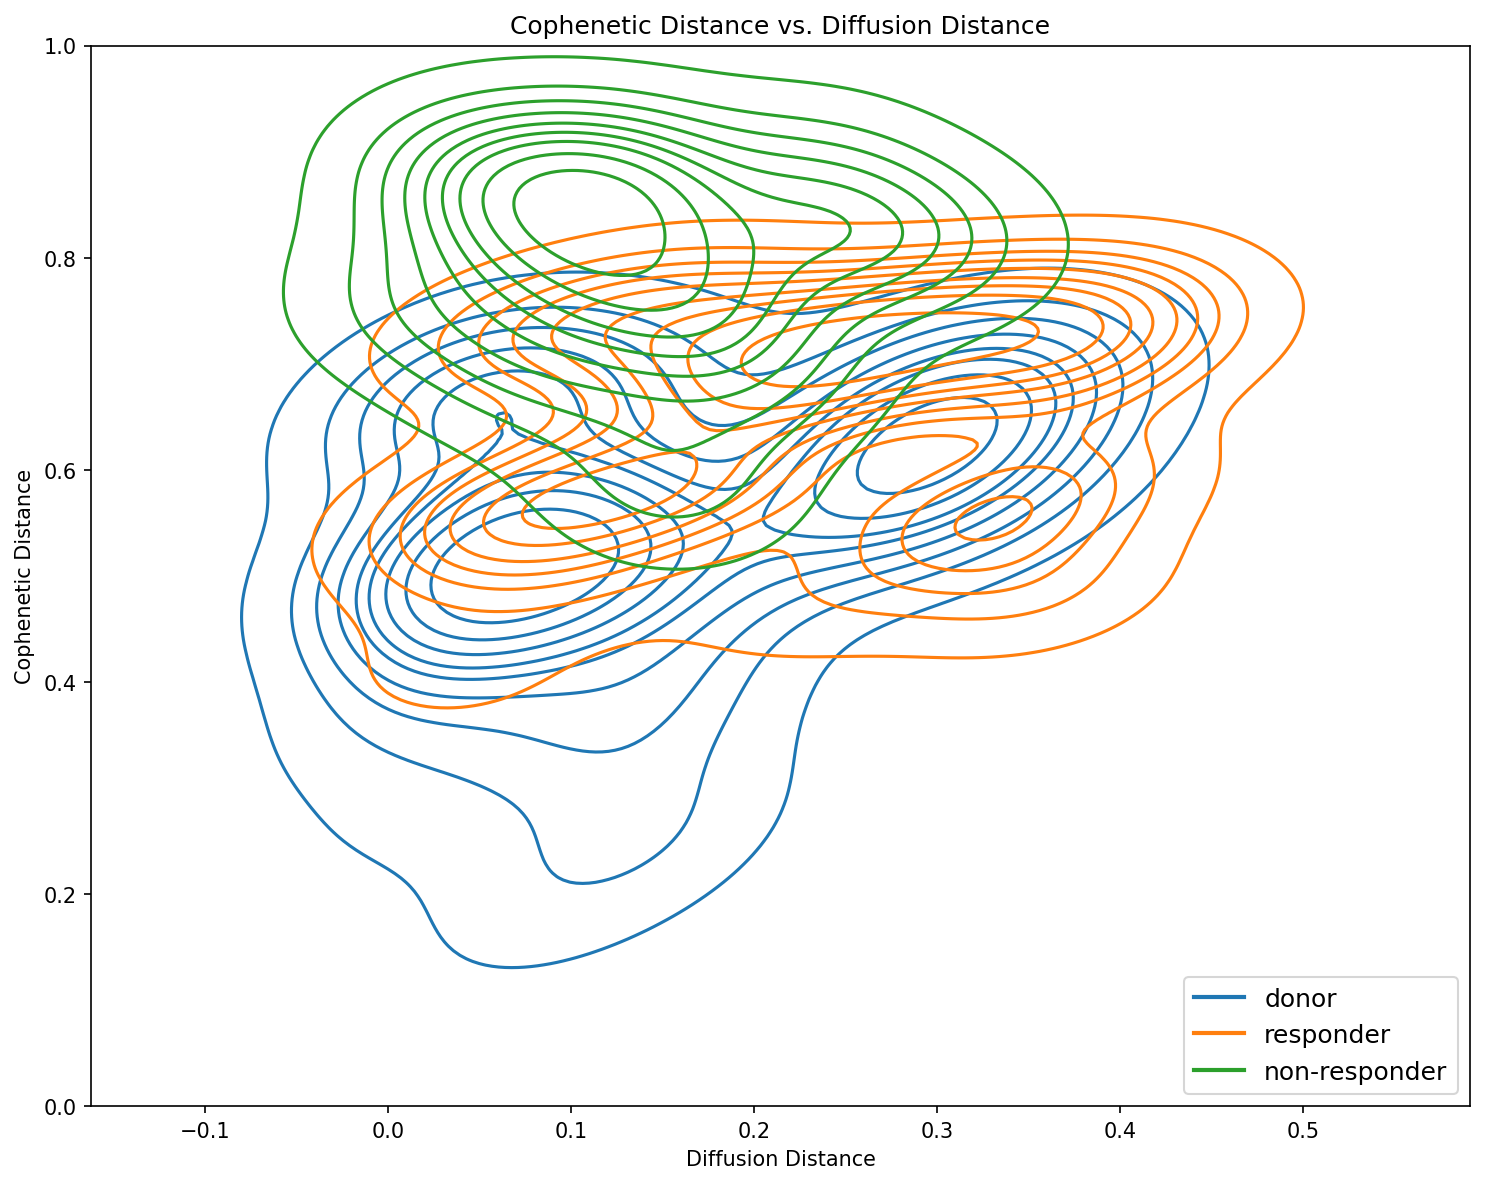

In [155]:
subset_samples_to_plot(['donor', 'responder', 'non-responder'])

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

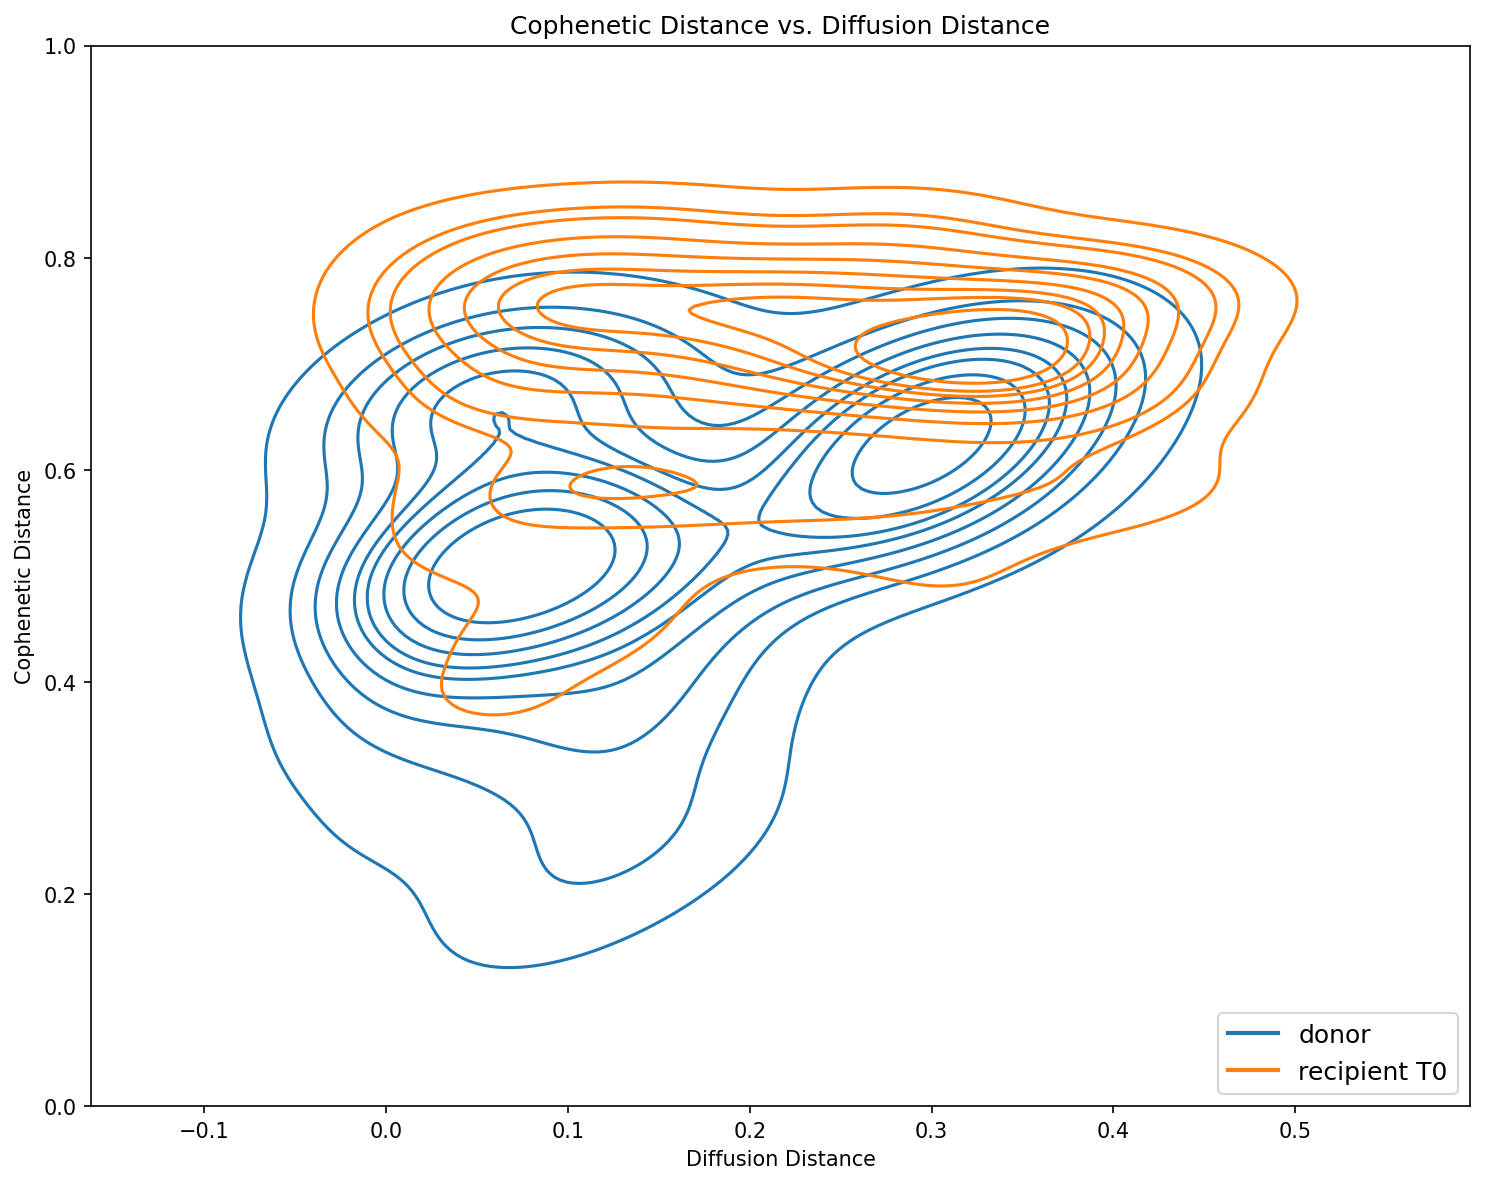

In [156]:
subset_samples_to_plot(['donor', 'recipient T0'])